In [1]:
!pip install ucimlrepo

**Step 1: Import Libraries**

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, confusion_matrix,
                           classification_report)

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# For fetching UCI dataset
from ucimlrepo import fetch_ucirepo

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


**Step 2: Fetch Dataset Directly from UCI**

In [3]:
print("="*60)
print("FETCHING GERMAN CREDIT DATASET FROM UCI")
print("="*60)

# Fetch dataset by ID 144
statlog_german_credit_data = fetch_ucirepo(id=144)

# Data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y_raw = statlog_german_credit_data.data.targets

print("\n📋 Dataset Information:")
print(f"   Dataset name: German Credit Data")
print(f"   Number of rows: {X.shape[0]}")
print(f"   Number of features: {X.shape[1]}")

# Check what y looks like
print(f"\n📋 Target variable raw data:")
print(f"   Type: {type(y_raw)}")
print(f"   Shape: {y_raw.shape if hasattr(y_raw, 'shape') else 'Unknown'}")
print(f"   First 10 values:\n{y_raw.head(10) if hasattr(y_raw, 'head') else y_raw[:10]}")

# Extract target values properly
if isinstance(y_raw, pd.DataFrame):
    # If it's a DataFrame, get the first column
    target_col = y_raw.columns[0]
    y = y_raw[target_col].copy()
    print(f"\n✅ Target column extracted: '{target_col}'")
elif isinstance(y_raw, pd.Series):
    y = y_raw.copy()
    print(f"\n✅ Target extracted as Series")
else:
    # Convert to Series if needed
    y = pd.Series(y_raw).copy()
    print(f"\n✅ Target converted to Series")

print(f"\n✅ Target variable shape: {y.shape}")
print(f"✅ Unique values in target: {y.unique()}")

print("\n✅ Dataset loaded successfully!")

FETCHING GERMAN CREDIT DATASET FROM UCI

📋 Dataset Information:
   Dataset name: German Credit Data
   Number of rows: 1000
   Number of features: 20

📋 Target variable raw data:
   Type: <class 'pandas.core.frame.DataFrame'>
   Shape: (1000, 1)
   First 10 values:
   class
0      1
1      2
2      1
3      1
4      2
5      1
6      1
7      1
8      1
9      2

✅ Target column extracted: 'class'

✅ Target variable shape: (1000,)
✅ Unique values in target: [1 2]

✅ Dataset loaded successfully!


**Step 3: Create Combined DataFrame and Inspect Data**

In [4]:
print("="*60)
print("CREATING COMBINED DATAFRAME")
print("="*60)

# Create a copy of features
df = X.copy()

# Add target to dataframe
df['credit_risk_raw'] = y

print("\n📊 Before mapping target values:")
print(f"   Value counts:\n{df['credit_risk_raw'].value_counts()}")

# Map target values according to UCI documentation
# In German Credit dataset: 1 = Good Credit, 2 = Bad Credit
# We'll convert to standard: 0 = Good Credit, 1 = Bad Credit
df['credit_risk'] = df['credit_risk_raw'].map({1: 0, 2: 1})

print("\n📊 After mapping target values:")
print(f"   Good Credit (0): {(df['credit_risk'] == 0).sum()}")
print(f"   Bad Credit  (1): {(df['credit_risk'] == 1).sum()}")
print(f"\n   Value counts:\n{df['credit_risk'].value_counts()}")

# Drop the raw target column
df = df.drop('credit_risk_raw', axis=1)

print(f"\n📊 Final dataframe shape: {df.shape}")
print(f"   Features: {df.shape[1] - 1} (excluding target)")
print(f"   Target included: Yes")

print("\n📋 First 5 rows of final dataframe:")
print(df.head())

CREATING COMBINED DATAFRAME

📊 Before mapping target values:
   Value counts:
credit_risk_raw
1    700
2    300
Name: count, dtype: int64

📊 After mapping target values:
   Good Credit (0): 700
   Bad Credit  (1): 300

   Value counts:
credit_risk
0    700
1    300
Name: count, dtype: int64

📊 Final dataframe shape: (1000, 21)
   Features: 20 (excluding target)
   Target included: Yes

📋 First 5 rows of final dataframe:
  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4 

**Step 4: Target Variable Analysis (Credit Risk Distribution)**

TARGET VARIABLE ANALYSIS

🎯 Credit Risk Distribution:
   Good Credit (0): 700 (70.0%)
   Bad Credit  (1): 300 (30.0%)


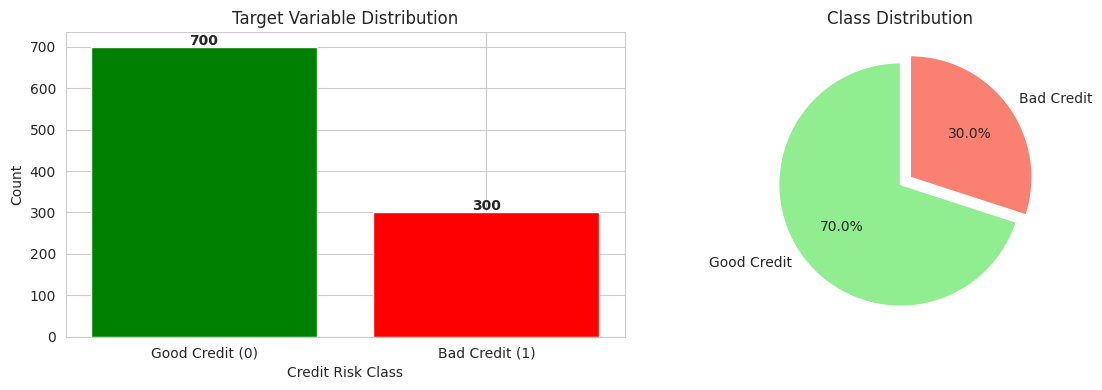


⚠️ Imbalance Ratio: 0.4286
   (This means 30.0% of customers are high-risk)
   → We need to handle this imbalance for better model performance!


In [5]:
print("="*60)
print("TARGET VARIABLE ANALYSIS")
print("="*60)

# Verify target column exists
if 'credit_risk' not in df.columns:
    print("❌ Error: 'credit_risk' column not found!")
    print(f"Available columns: {df.columns.tolist()}")
else:
    # Check target distribution
    target_dist = df['credit_risk'].value_counts()
    target_dist_pct = df['credit_risk'].value_counts(normalize=True) * 100
    
    print(f"\n🎯 Credit Risk Distribution:")
    print(f"   Good Credit (0): {target_dist.get(0, 0):,} ({target_dist_pct.get(0, 0):.1f}%)")
    print(f"   Bad Credit  (1): {target_dist.get(1, 0):,} ({target_dist_pct.get(1, 0):.1f}%)")
    
    # Only create plots if we have data
    if target_dist.get(0, 0) > 0 or target_dist.get(1, 0) > 0:
        try:
            # Visualize imbalance
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            # Bar plot
            axes[0].bar(['Good Credit (0)', 'Bad Credit (1)'], 
                        [target_dist.get(0, 0), target_dist.get(1, 0)], 
                        color=['green', 'red'])
            axes[0].set_title('Target Variable Distribution')
            axes[0].set_ylabel('Count')
            axes[0].set_xlabel('Credit Risk Class')
            
            # Add value labels on bars
            for i, v in enumerate([target_dist.get(0, 0), target_dist.get(1, 0)]):
                axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
            
            # Pie chart - only if both values are valid
            values = [target_dist.get(0, 0), target_dist.get(1, 0)]
            labels = ['Good Credit', 'Bad Credit']
            colors_pie = ['lightgreen', 'salmon']
            explode = (0, 0.1) if values[1] > 0 else (0, 0)
            
            axes[1].pie(values, 
                        labels=labels, 
                        autopct='%1.1f%%', 
                        colors=colors_pie,
                        explode=explode,
                        startangle=90)
            axes[1].set_title('Class Distribution')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"\n⚠️ Plotting error: {e}")
            print("Displaying text summary instead:")
            print(f"   Good Credit: {target_dist.get(0, 0)} ({target_dist_pct.get(0, 0):.1f}%)")
            print(f"   Bad Credit: {target_dist.get(1, 0)} ({target_dist_pct.get(1, 0):.1f}%)")
    else:
        print("\n⚠️ Warning: No data found in target variable!")
        print(f"Target unique values: {df['credit_risk'].unique()}")
        print(f"Target value counts:\n{df['credit_risk'].value_counts()}")
    
    # Calculate imbalance ratio
    if target_dist.get(0, 0) > 0:
        imbalance_ratio = target_dist.get(1, 0) / target_dist.get(0, 0)
        print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.4f}")
        print(f"   (This means {target_dist_pct.get(1, 0):.1f}% of customers are high-risk)")
        if imbalance_ratio < 0.5:
            print("   → We need to handle this imbalance for better model performance!")
        else:
            print("   → Dataset is relatively balanced")
    else:
        print("\n⚠️ Cannot calculate imbalance ratio (no Good Credit samples)")

In [6]:
# Verify data is correct
print("VERIFICATION CHECK")
print("="*40)
print(f"Dataset shape: {df.shape}")
print(f"Target column exists: {'credit_risk' in df.columns}")
print(f"Target values: {df['credit_risk'].unique()}")
print(f"Target counts:\n{df['credit_risk'].value_counts()}")
print(f"\nSample of data:")
print(df.head(3))
print("\n✅ If you see counts for Good and Bad, proceed to Step 5!")

VERIFICATION CHECK
Dataset shape: (1000, 21)
Target column exists: True
Target values: [0 1]
Target counts:
credit_risk
0    700
1    300
Name: count, dtype: int64

Sample of data:
  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A143        A152            2        A173            1   
1           22        A143        A152            1        A1

**Step 5: Check for Missing Values**

In [7]:
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)

# Check missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing_df)
else:
    print("\n✅ No missing values found in this dataset!")

# Double-check for nulls
print(f"\nTotal missing values in entire dataset: {df.isnull().sum().sum()}")

MISSING VALUES CHECK

✅ No missing values found in this dataset!

Total missing values in entire dataset: 0



**Step 6: Handle Categorical Variables (Encoding)The German Credit dataset contains many categorical features[^9]. We need to encode them for machine learning.**


In [8]:
print("="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Identify categorical columns (excluding the target)
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop('credit_risk') if 'credit_risk' in numerical_cols else numerical_cols

print(f"\n📊 Found {len(categorical_cols)} categorical features:")
for col in categorical_cols:
    print(f"   - {col}: {df[col].nunique()} unique values")

print(f"\n📊 Found {len(numerical_cols)} numerical features:")
for col in numerical_cols:
    print(f"   - {col}")

# Encode categorical variables using Label Encoding
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"✅ Encoded column: {col}")

print("\n✅ All categorical variables encoded!")

# Verify no object columns remain
print(f"\nRemaining object columns: {df_encoded.select_dtypes(include=['object']).columns.tolist()}")

ENCODING CATEGORICAL VARIABLES

📊 Found 13 categorical features:
   - Attribute1: 4 unique values
   - Attribute3: 5 unique values
   - Attribute4: 10 unique values
   - Attribute6: 5 unique values
   - Attribute7: 5 unique values
   - Attribute9: 4 unique values
   - Attribute10: 3 unique values
   - Attribute12: 4 unique values
   - Attribute14: 3 unique values
   - Attribute15: 3 unique values
   - Attribute17: 4 unique values
   - Attribute19: 2 unique values
   - Attribute20: 2 unique values

📊 Found 7 numerical features:
   - Attribute2
   - Attribute5
   - Attribute8
   - Attribute11
   - Attribute13
   - Attribute16
   - Attribute18
✅ Encoded column: Attribute1
✅ Encoded column: Attribute3
✅ Encoded column: Attribute4
✅ Encoded column: Attribute6
✅ Encoded column: Attribute7
✅ Encoded column: Attribute9
✅ Encoded column: Attribute10
✅ Encoded column: Attribute12
✅ Encoded column: Attribute14
✅ Encoded column: Attribute15
✅ Encoded column: Attribute17
✅ Encoded column: Attribute

**Step 7: Separate Features and Target**

In [9]:
print("="*60)
print("SEPARATING FEATURES AND TARGET")
print("="*60)

# Separate features and target
X = df_encoded.drop('credit_risk', axis=1)
y = df_encoded['credit_risk']

print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"   {X.shape[1]} features")
print(f"📊 Target vector shape: {y.shape}")
print(f"   {y.sum()} risky customers (Class 1), {len(y)-y.sum()} good customers (Class 0)")

# Feature names
print(f"\n📋 Feature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

SEPARATING FEATURES AND TARGET

📊 Feature matrix shape: (1000, 20)
   20 features
📊 Target vector shape: (1000,)
   300 risky customers (Class 1), 700 good customers (Class 0)

📋 Feature columns:
    1. Attribute1
    2. Attribute2
    3. Attribute3
    4. Attribute4
    5. Attribute5
    6. Attribute6
    7. Attribute7
    8. Attribute8
    9. Attribute9
   10. Attribute10
   11. Attribute11
   12. Attribute12
   13. Attribute13
   14. Attribute14
   15. Attribute15
   16. Attribute16
   17. Attribute17
   18. Attribute18
   19. Attribute19
   20. Attribute20


**Step 8: Split Data into Train and Test Sets**

In [10]:
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n📊 Training set: {X_train.shape[0]} samples")
print(f"   Class 0 (Good): {(y_train == 0).sum()}")
print(f"   Class 1 (Bad):  {(y_train == 1).sum()}")
print(f"\n📊 Test set: {X_test.shape[0]} samples")
print(f"   Class 0 (Good): {(y_test == 0).sum()}")
print(f"   Class 1 (Bad):  {(y_test == 1).sum()}")

print("\n✅ Stratified split complete - class proportions preserved!")

TRAIN-TEST SPLIT

📊 Training set: 800 samples
   Class 0 (Good): 560
   Class 1 (Bad):  240

📊 Test set: 200 samples
   Class 0 (Good): 140
   Class 1 (Bad):  60

✅ Stratified split complete - class proportions preserved!


**Step 9: Feature ScalingStep 9: Feature Scaling**

In [11]:
print("="*60)
print("FEATURE SCALING")
print("="*60)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print("   (mean=0, standard deviation=1)")

# Show scaling example
print("\n📊 Scaling example (first feature):")
print(f"   Before scaling - Mean: {X_train.iloc[:, 0].mean():.4f}, Std: {X_train.iloc[:, 0].std():.4f}")
print(f"   After scaling  - Mean: {X_train_scaled[:, 0].mean():.4f}, Std: {X_train_scaled[:, 0].std():.4f}")

FEATURE SCALING
✅ Features scaled using StandardScaler
   (mean=0, standard deviation=1)

📊 Scaling example (first feature):
   Before scaling - Mean: 1.5800, Std: 1.2582
   After scaling  - Mean: -0.0000, Std: 1.0000


**Step 10: Handle Class Imbalance with SMOTE**

In [12]:
print("="*60)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*60)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Check new distribution
print(f"\n📊 Before SMOTE:")
print(f"   Class 0 (Good): {(y_train == 0).sum()}")
print(f"   Class 1 (Bad):  {(y_train == 1).sum()}")

print(f"\n📊 After SMOTE:")
print(f"   Class 0 (Good): {(y_train_balanced == 0).sum()}")
print(f"   Class 1 (Bad):  {(y_train_balanced == 1).sum()}")
print(f"   ✅ Balanced dataset created!")

print(f"\n📊 Training set increased from {len(y_train)} to {len(y_train_balanced)} samples")

HANDLING CLASS IMBALANCE WITH SMOTE

📊 Before SMOTE:
   Class 0 (Good): 560
   Class 1 (Bad):  240

📊 After SMOTE:
   Class 0 (Good): 560
   Class 1 (Bad):  560
   ✅ Balanced dataset created!

📊 Training set increased from 800 to 1120 samples


**Step 11: Train Multiple Models and Compare**

MODEL TRAINING & COMPARISON

📊 Training Logistic Regression...
   ✅ Accuracy:  0.7350
   ✅ Precision: 0.5443
   ✅ Recall:    0.7167
   ✅ F1-Score:  0.6187
   ✅ ROC-AUC:   0.7915

📊 Training Decision Tree...
   ✅ Accuracy:  0.6550
   ✅ Precision: 0.4366
   ✅ Recall:    0.5167
   ✅ F1-Score:  0.4733
   ✅ ROC-AUC:   0.5968

📊 Training Random Forest...
   ✅ Accuracy:  0.7650
   ✅ Precision: 0.6226
   ✅ Recall:    0.5500
   ✅ F1-Score:  0.5841
   ✅ ROC-AUC:   0.7870

MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.735   0.544304 0.716667  0.618705 0.791548
      Decision Tree     0.655   0.436620 0.516667  0.473282 0.596786
      Random Forest     0.765   0.622642 0.550000  0.584071 0.787024


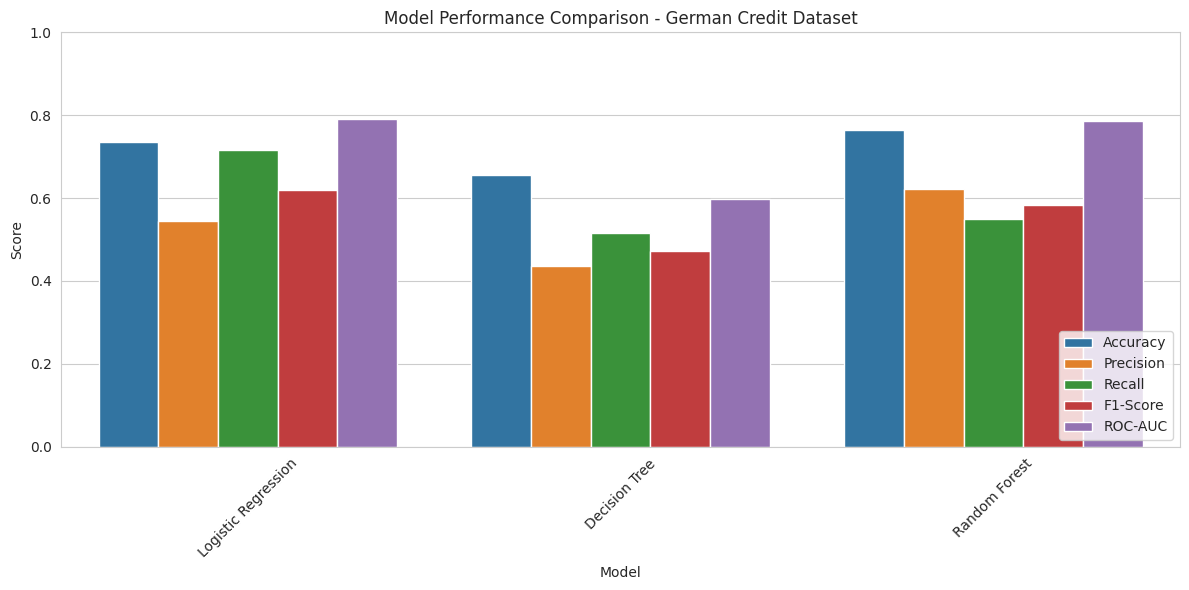

In [13]:
print("="*60)
print("MODEL TRAINING & COMPARISON")
print("="*60)

# Define models with class_weight='balanced' for handling imbalance
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, n_jobs=-1)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    
    # Train on balanced data
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"   ✅ Accuracy:  {accuracy:.4f}")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall:    {recall:.4f}")
    print(f"   ✅ F1-Score:  {f1:.4f}")
    print(f"   ✅ ROC-AUC:   {roc_auc:.4f}")

# Compare results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
results_df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_df_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison - German Credit Dataset')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Step 12: Best Model Detailed Evaluation**

BEST MODEL DETAILED EVALUATION

🏆 Best Model: Logistic Regression

📊 Confusion Matrix:
              Predicted Good  Predicted Bad
Actual Good:         104           36
Actual Bad:           17           43

📊 Confusion Matrix Interpretation:
   True Negatives (TN): 104 - Correctly predicted Good Credit
   False Positives (FP): 36 - Good customers wrongly labeled as Bad
   False Negatives (FN): 17 - Bad customers missed (most costly!)
   True Positives (TP): 43 - Correctly identified Bad customers

📋 Detailed Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.86      0.74      0.80       140
  Bad Credit       0.54      0.72      0.62        60

    accuracy                           0.73       200
   macro avg       0.70      0.73      0.71       200
weighted avg       0.76      0.73      0.74       200



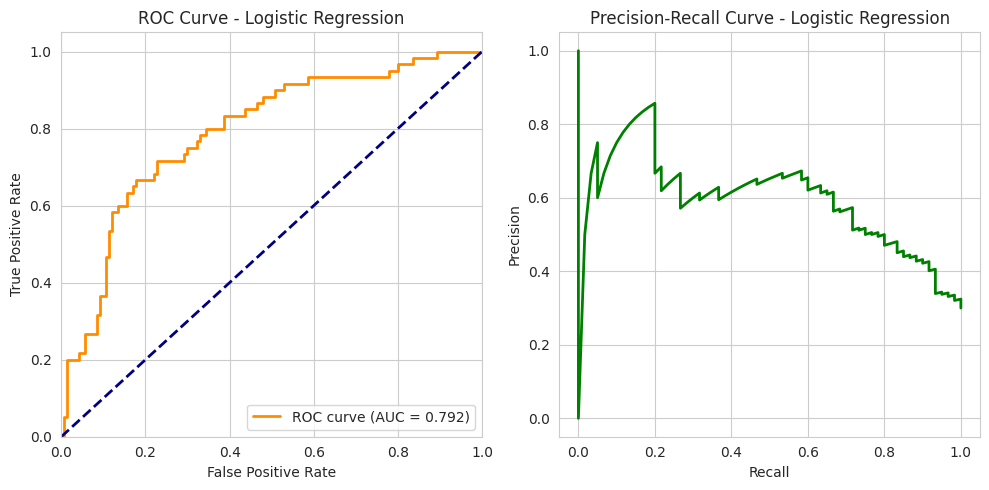

In [14]:
print("="*60)
print("BEST MODEL DETAILED EVALUATION")
print("="*60)

# Select best model (based on ROC-AUC)
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = models[best_model_name]

# Retrain on full balanced data
best_model.fit(X_train_balanced, y_train_balanced)

print(f"\n🏆 Best Model: {best_model_name}")

# Predictions
y_pred_final = best_model.predict(X_test_scaled)
y_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
print(f"\n📊 Confusion Matrix:")
print(f"              Predicted Good  Predicted Bad")
print(f"Actual Good:      {cm[0,0]:>6}       {cm[0,1]:>6}")
print(f"Actual Bad:       {cm[1,0]:>6}       {cm[1,1]:>6}")

# Interpretation
print(f"\n📊 Confusion Matrix Interpretation:")
print(f"   True Negatives (TN): {cm[0,0]} - Correctly predicted Good Credit")
print(f"   False Positives (FP): {cm[0,1]} - Good customers wrongly labeled as Bad")
print(f"   False Negatives (FN): {cm[1,0]} - Bad customers missed (most costly!)")
print(f"   True Positives (TP): {cm[1,1]} - Correctly identified Bad customers")

# Classification Report
print(f"\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Good Credit', 'Bad Credit']))

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
roc_auc = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.grid(True)

# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_final)

plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.grid(True)

plt.tight_layout()
plt.show()

**Step 13: Feature Importance Analysis**

FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Influential Features for Logistic Regression:
    Feature  Coefficient
 Attribute8     0.354540
Attribute12     0.350302
 Attribute2     0.333208
 Attribute5     0.216907
Attribute16     0.073493
Attribute18     0.067042
Attribute17     0.018916
Attribute13    -0.002901
Attribute10    -0.053798
 Attribute4    -0.058427


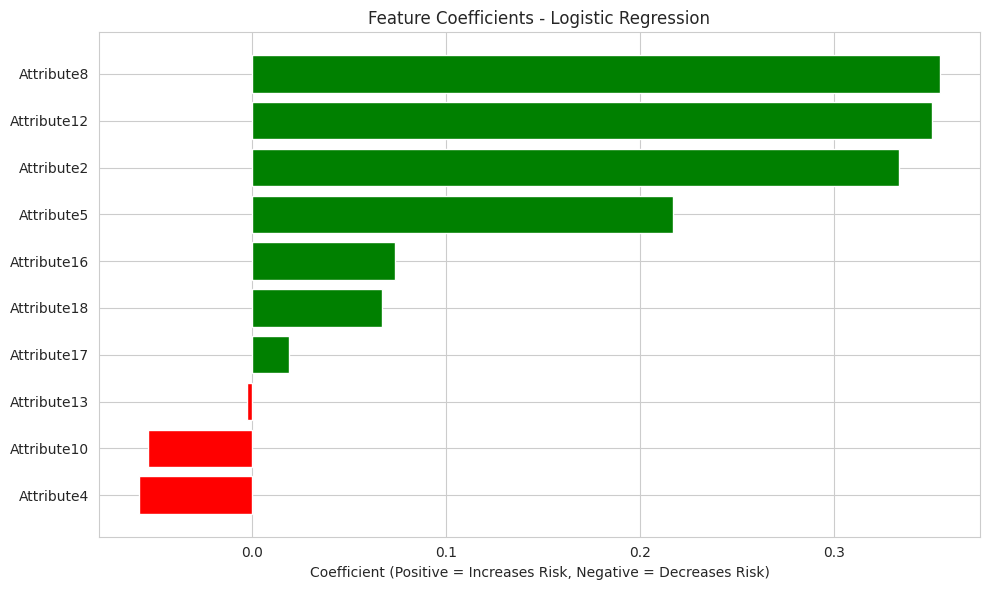

In [15]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Check if model has feature_importances_ attribute
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Create DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\n📊 Top 10 Most Important Features for {best_model_name}:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_features = feature_importance_df.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
elif best_model_name == 'Logistic Regression':
    # For Logistic Regression, show coefficients
    coefficients = best_model.coef_[0]
    feature_names = X.columns
    
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)
    
    print(f"\n📊 Top 10 Most Influential Features for {best_model_name}:")
    print(coef_df.head(10).to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    top_coef = coef_df.head(10)
    colors = ['red' if x < 0 else 'green' for x in top_coef['Coefficient']]
    plt.barh(range(len(top_coef)), top_coef['Coefficient'], color=colors)
    plt.yticks(range(len(top_coef)), top_coef['Feature'])
    plt.xlabel('Coefficient (Positive = Increases Risk, Negative = Decreases Risk)')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


**Step 14: Cost Matrix Analysis (Important for Credit Scoring)The German Credit dataset has a cost matrix where:Classifying a Bad customer as Good costs 5 unitsClassifying a Good customer as Bad costs 1 unitThis means False Negatives are 5x more costly than False Positives.**


In [16]:
print("="*60)
print("COST MATRIX ANALYSIS")
print("="*60)

# Cost matrix from UCI documentation[citation:9]
# Rows: Actual, Columns: Predicted
#           Predicted Good  Predicted Bad
# Actual Good     0              1
# Actual Bad      5              0

cm = confusion_matrix(y_test, y_pred_final)

# Calculate cost
FN_cost = 5  # Bad customer misclassified as Good (most expensive)
FP_cost = 1  # Good customer misclassified as Bad

total_cost = (cm[1, 0] * FN_cost) + (cm[0, 1] * FP_cost)

print(f"\n💰 Cost Matrix:")
print(f"   ┌─────────────────────┬─────────────────┬─────────────────┐")
print(f"   │                     │  Predicted Good  │  Predicted Bad  │")
print(f"   ├─────────────────────┼─────────────────┼─────────────────┤")
print(f"   │  Actual Good        │    Cost: 0      │    Cost: {FP_cost}       │")
print(f"   ├─────────────────────┼─────────────────┼─────────────────┤")
print(f"   │  Actual Bad         │    Cost: {FN_cost}      │    Cost: 0      │")
print(f"   └─────────────────────┴─────────────────┴─────────────────┘")

print(f"\n📊 Confusion Matrix from our model:")
print(f"              Predicted Good  Predicted Bad")
print(f"Actual Good:      {cm[0,0]:>6}       {cm[0,1]:>6}")
print(f"Actual Bad:       {cm[1,0]:>6}       {cm[1,1]:>6}")

print(f"\n💰 Total Cost of our model:")
print(f"   FN (Bad as Good): {cm[1,0]} × {FN_cost} = {cm[1,0] * FN_cost}")
print(f"   FP (Good as Bad): {cm[0,1]} × {FP_cost} = {cm[0,1] * FP_cost}")
print(f"   ──────────────────────────────────────")
print(f"   TOTAL COST: {total_cost}")

# Try to find optimal threshold to minimize cost
print(f"\n🔍 Finding optimal threshold to minimize cost...")

best_threshold = 0.5
best_cost = total_cost
thresholds_tried = []

for threshold in np.arange(0.3, 0.8, 0.05):
    y_pred_thresh = (y_proba_final >= threshold).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    cost_thresh = (cm_thresh[1, 0] * FN_cost) + (cm_thresh[0, 1] * FP_cost)
    thresholds_tried.append((threshold, cost_thresh))
    
    if cost_thresh < best_cost:
        best_cost = cost_thresh
        best_threshold = threshold

print(f"\n📊 Optimal threshold: {best_threshold:.2f}")
print(f"   Minimum cost at this threshold: {best_cost}")
print(f"   Cost reduction: {total_cost - best_cost} ({(1 - best_cost/total_cost)*100:.1f}% improvement)")

# Apply optimal threshold
y_pred_optimal = (y_proba_final >= best_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

print(f"\n📊 Confusion Matrix with optimal threshold ({best_threshold:.2f}):")
print(f"              Predicted Good  Predicted Bad")
print(f"Actual Good:      {cm_optimal[0,0]:>6}       {cm_optimal[0,1]:>6}")
print(f"Actual Bad:       {cm_optimal[1,0]:>6}       {cm_optimal[1,1]:>6}")

COST MATRIX ANALYSIS

💰 Cost Matrix:
   ┌─────────────────────┬─────────────────┬─────────────────┐
   │                     │  Predicted Good  │  Predicted Bad  │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Good        │    Cost: 0      │    Cost: 1       │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Bad         │    Cost: 5      │    Cost: 0      │
   └─────────────────────┴─────────────────┴─────────────────┘

📊 Confusion Matrix from our model:
              Predicted Good  Predicted Bad
Actual Good:         104           36
Actual Bad:           17           43

💰 Total Cost of our model:
   FN (Bad as Good): 17 × 5 = 85
   FP (Good as Bad): 36 × 1 = 36
   ──────────────────────────────────────
   TOTAL COST: 121

🔍 Finding optimal threshold to minimize cost...

📊 Optimal threshold: 0.30
   Minimum cost at this threshold: 107
   Cost reduction: 14 (11.6% improvement)

📊 Confusion Matrix with optimal threshold (0.30):
 

**Step 15: Save the Model**

In [17]:
print("="*60)
print("SAVING THE MODEL")
print("="*60)

import joblib

# Save model, scaler, and feature names
joblib.dump(best_model, 'german_credit_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("✅ Model saved as 'german_credit_model.pkl'")
print("✅ Scaler saved as 'feature_scaler.pkl'")
print("✅ Feature names saved as 'feature_names.pkl'")

# Example: Load and use the model
print("\n📝 Example: Loading and using the model")
loaded_model = joblib.load('german_credit_model.pkl')
loaded_scaler = joblib.load('feature_scaler.pkl')
loaded_features = joblib.load('feature_names.pkl')

# Example prediction on a sample customer
sample_customer = X_test.iloc[0:1]
sample_scaled = loaded_scaler.transform(sample_customer)
prediction = loaded_model.predict(sample_scaled)
probability = loaded_model.predict_proba(sample_scaled)[0, 1]

print(f"\n🏦 Sample Customer Prediction:")
print(f"   Default Probability: {probability:.2%}")
print(f"   Credit Decision: {'DENIED' if prediction[0] == 1 else 'APPROVED'}")

SAVING THE MODEL
✅ Model saved as 'german_credit_model.pkl'
✅ Scaler saved as 'feature_scaler.pkl'
✅ Feature names saved as 'feature_names.pkl'

📝 Example: Loading and using the model

🏦 Sample Customer Prediction:
   Default Probability: 28.84%
   Credit Decision: APPROVED


**Step 16: Final Summary Report**

In [18]:
print("="*60)
print("PROJECT SUMMARY REPORT")
print("="*60)

print(f"""
📊 DATASET INFORMATION:
   • Dataset: German Credit Data (UCI Statlog)
   • Total samples: {len(df)}
   • Features: {X.shape[1]}
   • Default rate: {y.mean():.1%}
   • Class imbalance handled: YES (SMOTE)

🎯 MODEL PERFORMANCE (Best: {best_model_name}):
   • Accuracy:  {results_df[results_df['Model']==best_model_name]['Accuracy'].values[0]:.4f}
   • Precision: {results_df[results_df['Model']==best_model_name]['Precision'].values[0]:.4f}
   • Recall:    {results_df[results_df['Model']==best_model_name]['Recall'].values[0]:.4f}
   • F1-Score:  {results_df[results_df['Model']==best_model_name]['F1-Score'].values[0]:.4f}
   • ROC-AUC:   {results_df[results_df['Model']==best_model_name]['ROC-AUC'].values[0]:.4f}

💰 COST ANALYSIS:
   • False Negative Cost (Bad → Good): 5 units
   • False Positive Cost (Good → Bad): 1 unit
   • Total Model Cost: {total_cost}
   • Optimal Threshold: {best_threshold:.2f}
   • Minimum Possible Cost: {best_cost}

🔧 COST MATRIX (Important for Credit Scoring):
   ┌─────────────────────┬─────────────────┬─────────────────┐
   │                     │  Predicted Good  │  Predicted Bad  │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Good        │    Cost: 0      │    Cost: 1      │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Bad         │    Cost: 5      │    Cost: 0      │
   └─────────────────────┴─────────────────┴─────────────────┘

📁 SAVED FILES:
   • german_credit_model.pkl - Trained model
   • feature_scaler.pkl - Standard scaler
   • feature_names.pkl - Feature column names

💡 KEY INSIGHTS:
   • Missing a bad customer (False Negative) is 5x more costly than 
     falsely flagging a good customer (False Positive)
   • The optimal threshold was adjusted to {best_threshold:.2f} to minimize total cost
   • Threshold optimization reduced total cost by {(1 - best_cost/total_cost)*100:.1f}%

💡 NEXT STEPS:
   1. Deploy model as API endpoint
   2. Monitor model performance over time
   3. Collect new data for retraining
   4. Add SHAP explanations for interpretability
""")

print("="*60)
print("✅ GERMAN CREDIT SCORING MODEL COMPLETED SUCCESSFULLY!")
print("="*60)

PROJECT SUMMARY REPORT

📊 DATASET INFORMATION:
   • Dataset: German Credit Data (UCI Statlog)
   • Total samples: 1000
   • Features: 20
   • Default rate: 30.0%
   • Class imbalance handled: YES (SMOTE)

🎯 MODEL PERFORMANCE (Best: Logistic Regression):
   • Accuracy:  0.7350
   • Precision: 0.5443
   • Recall:    0.7167
   • F1-Score:  0.6187
   • ROC-AUC:   0.7915

💰 COST ANALYSIS:
   • False Negative Cost (Bad → Good): 5 units
   • False Positive Cost (Good → Bad): 1 unit
   • Total Model Cost: 121
   • Optimal Threshold: 0.30
   • Minimum Possible Cost: 107

🔧 COST MATRIX (Important for Credit Scoring):
   ┌─────────────────────┬─────────────────┬─────────────────┐
   │                     │  Predicted Good  │  Predicted Bad  │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Good        │    Cost: 0      │    Cost: 1      │
   ├─────────────────────┼─────────────────┼─────────────────┤
   │  Actual Bad         │    Cost: 5      │    Cost: 0      │
   └──